<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>🍿Netflix</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<details>
  <summary><small>Sharing consent: <mark>[ X ]</mark></summary>
  <div>
We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is <b>optional</b> and this decision will not affect our grade in any way. <font color=gray><i>
Instructions: If ok with sharing your Colab for educational purposes, leave "X" in the check box.</i></font></small></div>

In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle                                           # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >>log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json >> log                  # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                              # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 260209-netflix           # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log                          # download competition dataset as a zip file
!unzip -o *.zip >> log                                        # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                       # print public leaderboard

cp: cannot stat 'kaggle.json': No such file or directory
- competition is now set to: 260209-netflix
100% 45.0M/45.0M [00:00<00:00, 1.60GB/s]
Using competition: 260209-netflix
  teamId  teamName                       submissionDate              score         
--------  -----------------------------  --------------------------  ------------  
15258278  Team 6                         2026-02-22 00:38:59.440000  0.4413000000  
15279032  2_Rose_Annalise                2026-02-22 19:35:19.596000  0.4323000000  
15255759  Team_3_Cho_Ho_Rhezaii          2026-02-23 04:53:02.116000  0.4299000000  
15268992  Team_7                         2026-02-22 17:25:02.236000  0.4288000000  
15260386  Matrix Factor-Action🍿 5        2026-02-23 02:56:36.333000  0.4210000000  
15259715  4_AndrewSAlexAStevenHQuinnanG  2026-02-23 00:56:49.656000  0.4200000000  
15225537  Team 8                         2026-02-23 04:46:16.550000  0.4170000000  
15219579  1_abalmasov_bajaj_yan          2026-02-23 01:40:56.493000 

In [ ]:
%%time
%%capture
%reset -f
# !cp metadata.json METADATA
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage, plotly.express as px #, surprise
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import TruncatedSVD
from scipy.sparse.linalg import svds
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals

class Timer():
  def __init__(self, lim:'RunTimeLimit'=120): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=1000, precision=2, edgeitems=20, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 2.5 s, sys: 288 ms, total: 2.78 s
Wall time: 2.82 s


<details>
  <summary><font size=5><b>About the data matrix</b></font></summary>
  <div>

The matrix below contains ratings that users (user id or `uid`) have given to the movies (movie ID or `mid`). It is 85% blank, but the original dataset was 99% sparse (with ~1 rating per user) [&#127910;](https://youtu.be/ImpV70uLxyw). Your task is not to fill the whole matrix, but to impute `NaN` values in `XY_Netflix.csv`, which is an equivalent representation of `XY_Netflix_matrix.csv`. This is a collaborative filtering problem, where observations and features have some implicit relation. Recall that typically we expect independent observations in a sample (unless we have a time series or video of image frames, etc.). Here our model needs to learn and leverage the dependencies from observed movie ratings. Clustering techniques might be more intuitive here. [Truncated SVD](https://scikit-learn.org/stable/modules/decomposition.html#lsa) is also popular. Supervised models can be used as well, if we can build features describing our users (which we would treat as observations). Note that we have no other information on users except what they have ranked (which might suggest the cluster they belong to, which might offer unobserved (latent) features). [&#127910;](https://youtu.be/8wLKuscyO9I) Since users relate to other users through the movies they ranked, this can also be presented as a [bipartite graph](https://en.wikipedia.org/wiki/Bipartite_graph).

</div> </details>

In [ ]:
dfMtx = pd.read_csv('XY_Netflix_matrix.csv', low_memory=False); dfMtx

,1,2,3,4,5,6,7,8,9,10,...,371,372,373,374,375,376,377,378,379,380
0,NaN,NaN,2.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,NaN,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128698,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
f = px.imshow(dfMtx.iloc[:2000,:].T, color_continuous_scale='RdBu_r', aspect='auto');  # movies by users (transposed for visual convenience)
f.update_layout(margin=dict(l=0,r=0,b=0,t=0))

In [ ]:
dfMtx.info()   # note the datatypes and any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128699 entries, 0 to 128698
Columns: 380 entries, 1 to 380
dtypes: float64(380)
memory usage: 373.1 MB


The dataframe below is another representation of the matrix form above. It lists the `uid`$\times$`mid`locations of the values you need to predict (those with `NaN`) and all other non-zero values in the matrix above.

In [ ]:
df = pd.read_csv('XY_Netflix.csv', low_memory=False); df  # user ID, movie ID, rating. NaN=requires predictions

,uid,mid,rtg
0,1,1,NaN
1,2,2,NaN
...,...,...,...
7402070,49692,126,4.0
7402071,9783,37,1.0


In [ ]:
df.rtg.fillna(0).astype(int).value_counts().to_frame().T   # rating frequencies. 0 represents NaN

rtg,4,3,5,2,1,0
count,2451087,2120585,1628122,842056,340222,20000


In [ ]:
dfMov = pd.read_csv('movies.csv'); dfMov.head(2)   # load movie attributes

,mid,Year,Name,voteAvg,voteCnt,popularity,duration,income,budget,releaseDate,...,origLang,spokenLang,ttl,origTtl,URL,kwds,desc,prodComp,prodCtry,tagline
0,1,2004,The Village,6.2,1071,27.49,108.0,256697520,60000000,7/30/04,...,en,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Village,The Village,NaN,"[{""id"": 1328, ""name"": ""secret""}, {""id"": 5774, ...",When a willful young man tries to venture beyo...,"[{""name"": ""Scott Rudin Productions"", ""id"": 258...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",There is no turning back
1,2,1997,Liar Liar,6.4,1424,26.72,86.0,181000000,45000000,3/21/97,...,en,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Liar Liar,Liar Liar,NaN,"[{""id"": 387, ""name"": ""california""}, {""id"": 102...",Fletcher Reede is a fast-talking attorney and ...,"[{""name"": ""Imagine Entertainment"", ""id"": 23}, ...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Trust me.


In [ ]:
tmr = Timer()

⏳ started. You have 120 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

<font color=green><h3><b>$\alpha$. Apply truncated SVD</b><h3>

In [ ]:
%%time
if 'dfMtx' in vars(): del dfMtx   # release ~400MB RAM
dfK = df[df.rtg!=df.rtg]          # uid-mid-rtg for Kaggle submission (NaN ratings)
dfX = df[df.uid.isin(dfK.uid.unique())]  # all ratings on users requiring predictions
dfX = dfX.pivot_table(index='uid', columns='mid', values='rtg')  # matrix format
n, p = dfX.shape
print(f"Matrix shape: {n} users x {p} movies")
np.random.seed(0)

def run_svd(dfX_train, k_svd=8, n_iters=10, movie_features=None):
    # Vectorized user-bias imputation
    global_mean = dfX_train.stack().mean()
    movie_bias = dfX_train.mean(axis=0) - global_mean # per-movie deviation
    user_bias = dfX_train.mean(axis=1) - global_mean # per-user deviation

    # Create bias matrix: each cell = global_mean + np.add.outer(user_bias.values, movie_bias.values)
    bias_matrix = global_mean + np.add.outer(user_bias.values, movie_bias.values)
    bias_df = pd.DataFrame(bias_matrix, index=dfX_train.index, columns=dfX_train.columns).clip(1, 5)

    # Fill only NaN positions with bias estimates
    dfX_est = dfX_train.copy()
    mask = dfX_train.isna()
    dfX_est[mask] = bias_df[mask]
    dfX_est = dfX_est.fillna(dfX_train.mean())  # any remaining edge cases

    # print(f"Global mean: {global_mean:.2f}, Imputation done.")

    loc = ~np.isnan(dfX_train) # mask of known ratings (precompute once)

    prev = np.zeros_like(dfX_est.to_numpy())
    tol = 1e-4


    for _ in range(n_iters):

        if movie_features is not None:
            # Transpose dfX_est to (movies x users) to allow horizontal stacking with movie_features (movies x features)
            dfX_est_transposed = dfX_est.to_numpy().T
            augmented = np.hstack([dfX_est_transposed, movie_features])
            U, D, Vt = svds(augmented, k=k_svd)
            # Reconstruct the augmented matrix and extract only the user-rating part, then transpose back
            reconstructed_augmented = U @ np.diag(D) @ Vt
            # The rating part corresponds to the first 'n' columns (number of users)
            dfX_est.loc[:, :] = reconstructed_augmented[:, :dfX_train.shape[0]].T
        else:
            U, D, Vt = svds(dfX_est.to_numpy(), k=k_svd)
            dfX_est.loc[:, :] = U @ np.diag(D) @ Vt
        dfX_est[loc] = dfX_train[loc]

    return dfX_est.clip(1, 5)

Matrix shape: 18364 users x 380 movies
CPU times: user 856 ms, sys: 102 ms, total: 957 ms
Wall time: 984 ms


In [ ]:
"""
Here is the more feature engineering involving the movie dataset
This is commented out because the movie data did not factor into the the
features
"""

# from sklearn.preprocessing import StandardScaler

# # Movie popularity features from ratings data
# movie_stats = df.dropna(subset=['rtg']).groupby('mid')['rtg'].agg(
#     n_ratings='count',
#     avg_rating='mean',
#     rating_std='std'
# ).fillna(0)

# # Year extracted from title
# dfMov['year'] = dfMov['Name'].str.extract(r'\((\d{4})\)').astype(float)

# # Combine into one feature dataframe, aligned to dfX columns (the 380 movies)
# dfMov_features = dfMov.set_index('mid')[['year']]\
#     .join(movie_stats)\
#     .reindex(dfX.columns)\
#     .fillna(0)

# # Scale and dampen so features don't overpower ratings
# scaled_features = StandardScaler().fit_transform(dfMov_features) * 10
# print(f"Movie features shape: {scaled_features.shape}")  # should be (380, 4)
# print(dfMov_features.head())

'\nHere is the more feature engineering involving the movie dataset\nThis is commented out because the movie data did not factor into the the\nfeatures\n'

In [ ]:
# %%time
# from sklearn.model_selection import KFold, StratifiedKFold
# from sklearn.metrics import mean_squared_error, accuracy_score, f1_score
# from sklearn.preprocessing import StandardScaler

# def smart_round(vals):
#     # bins = [1.8, 2.6, 3.4, 4.1]
#     # bins = [1.8, 2.6, 3.4, 4.3]
#     # bins = [1.9 , 2.35, 3.43, 4.28]
#     bins = [1.8, 2.6, 3.4, 4.3]
#     return np.digitize(vals, bins) + 1

# def fit_smart_round(continuous_preds, actual_ratings):
#     """Find bins that best match the true rating distribution."""
#     from scipy.optimize import minimize

#     def neg_accuracy(bins):
#         bins = np.sort(bins)  # keep ordered
#         predicted = np.digitize(continuous_preds, bins) + 1
#         return -accuracy_score(actual_ratings, predicted)

#     result = minimize(neg_accuracy, x0=[1.8, 2.6, 3.4, 4.3], method='Nelder-Mead')
#     best_bins = np.sort(result.x)
#     print(f"Optimized bins: {best_bins.round(3)}")
#     return best_bins

# known_mask = ~dfX.isna()
# known_positions = list(zip(*np.where(known_mask.values)))
# known_values = np.array([dfX.iloc[i, j] for i, j in known_positions]) # Convert to numpy array

# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# acc_scores = []
# f1_scores = []

# bin_patterns = []

# # Pass known_values as the second argument to split()
# for fold, (train_idx, val_idx) in enumerate(kf.split(known_positions, known_values)):
#     # Build a training matrix with val ratings hidden
#     dfX_train = dfX.copy()
#     val_positions = [known_positions[i] for i in val_idx]
#     for (i, j) in val_positions:
#         dfX_train.iloc[i, j] = np.nan

#     # Run SVD on the training matrix
#     dfX_pred = run_svd(dfX_train, k_svd=5, n_iters=150, movie_features=None)

#     # Evaluate on hidden ratings
#     actual = np.array([dfX.iloc[i, j] for i, j in val_positions])
#     continuous_val_preds = np.array([dfX_pred.iloc[i, j] for i, j in val_positions])

#     # Find the best bins using the continuous predictions and actual ratings
#     best_bins = fit_smart_round(continuous_val_preds, actual)
#     bin_patterns.append(best_bins)

#     # Use the best_bins to discretize the continuous predictions for evaluation
#     predicted = np.digitize(continuous_val_preds, best_bins) + 1
#     # predicted = smart_round(continuous_val_preds)

#     acc = accuracy_score(actual, predicted)
#     acc_scores.append(acc)
#     print(f"Fold {fold+1} Accuracy: {acc:.4f}")

#     f1 = f1_score(actual, predicted, average='weighted')
#     f1_scores.append(f1)
#     print(f"Fold {fold+1} F1 Score: {f1:.4f}")

# bin_patterns = np.array(bin_patterns)
# print(np.average(bin_patterns, axis=0))


# print(f"\nMean Accuracy: {np.mean(acc_scores):.4f} \u00B1 {np.std(acc_scores):.4f}")
# print(f"Mean F1-Score: {np.mean(f1_scores):.4f} \u00B1 {np.std(f1_scores):.4f}\n")

In [ ]:
# %%time
# np.random.seed(0)

# #Tuned parameters
k_svd = 5 # latent dimensions (~perceived genre count)
n_iters = 10 # SVD iterations

dfX_est = run_svd(dfX, k_svd=k_svd, n_iters=n_iters)

In [ ]:
# # Fit bins on all known ratings
# known_preds = np.array([dfX_est.iloc[i, j] for i, j in known_positions])
# known_actual = np.array(known_values, dtype=int)
# best_bins = fit_smart_round(known_preds, known_actual)

# # Convert to tall format
# dfX_est_L = dfX_est.unstack().reset_index().rename(columns={0:'rtg'})

# # Merge with Kaggle submission keys
# dfK = dfX_est_L.merge(
#     df[df.rtg!=df.rtg][['uid','mid']],
#     on=['mid','uid']
# )
# dfK.index = (dfK.uid - 1) * dfK.mid.max() + dfK.mid

# # Use optimized bins instead of hardcoded ones
# dfK['rtg'] = smart_round(dfK['rtg'].values, bins=best_bins)

# print("Predicted distribution:")
# print(dfK['rtg'].value_counts().sort_index())
# print(f"\nTotal predictions: {len(dfK)}")

In [ ]:
%%time

# Convert to tall format
dfX_est_L = dfX_est.unstack().reset_index().rename(columns={0:'rtg'})

# bins = [1.9 , 2.35, 3.43, 4.28]

def smart_round(vals):
    # bins = [1.8, 2.6, 3.4, 4.1]
    # bins = [1.8, 2.6, 3.4, 4.3]
    # bins = [1.9 , 2.35, 3.43, 4.28]
    bins = [1.95, 2.39, 3.45, 4.23]
    # bins = [1.82, 2.27, 3.43, 4.27]
    return np.digitize(vals, bins) + 1

# Merge with Kaggle submission keys
dfK = dfX_est_L.merge(
    df[df.rtg!=df.rtg][['uid','mid']],
    on=['mid','uid']
)
dfK.index = (dfK.uid - 1) * dfK.mid.max() + dfK.mid


dfK['rtg'] = smart_round(dfK['rtg'].values)
# dfK['rtg'] = dfK['rtg'].clip(1, 5)

print("Predicted distribution:")
print(dfK['rtg'].value_counts().sort_index())
print(f"\nTotal predictions: {len(dfK)}")


Predicted distribution:
rtg
1     147
2     457
     ... 
4    8950
5    3105
Name: count, Length: 5, dtype: int64

Total predictions: 20000
CPU times: user 7.02 s, sys: 742 ms, total: 7.77 s
Wall time: 7.86 s


<Axes: >

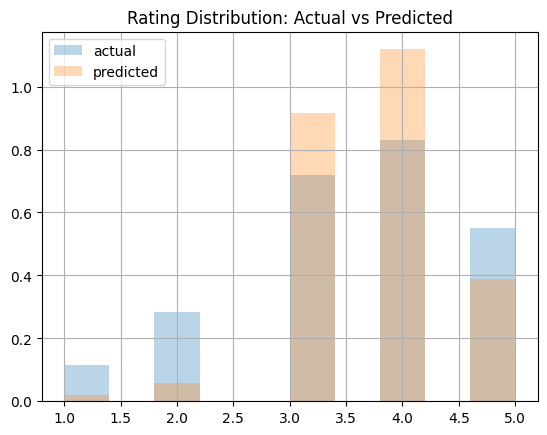

In [ ]:
# Compare actual vs predicted rating distributions
plt.subplot(1, 1, 1)
_ = df.rtg.dropna(axis=0).astype(int).hist(density=True, alpha=0.3);
_ = dfK.rtg.astype(int).hist(density=True, alpha=0.3);
_ = plt.legend(['actual','predicted']);
_ = plt.title('Rating Distribution: Actual vs Predicted')


In [ ]:
ToCSV(dfK[['rtg']].sort_index(), 'Netflix_Submission')
print("Saved: Netflix_Submission.csv")


Saved: Netflix_Submission.csv


<font color=green><h3><b>$\gamma$. Idea Documentation</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


<font color=green><h4><b>Task 1. Preprocessing Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped in <b>preprocessing pipeline</b>. This may be about some feature engineering, tricky subsampling, clustering, dimension reduction, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: User-Bias Imputation for Missing Rating Initialization
1. **Idea Discovery**: The baseline fills missing ratings with movie column means, ignoring that users have individual rating tendencies (some rate generously, others harshly). The FA24 rank-2 team (Acc=0.4176) found that "Simon Funk initialization" — incorporating user-specific biases — led to marginal accuracy gains [7]. SP25 rank-3 (Acc=0.4125) also retained user bias imputation in their final solution.
1. **Finding's Importance**: In collaborative filtering, user bias is a strong signal: a user who rates everything 4-5 will likely rate an unseen movie higher than a user who rates 2-3. By initializing missing values as `global_mean + user_bias + movie_bias`, the SVD starts from a more informed estimate, converging faster and more accurately than from column means alone.
1. **Experiment Setup**: (a) Baseline: fill NaN with movie column mean → SVD k=3, 3 iters. (b) Our approach: compute global mean, per-user bias (user avg - global mean), per-movie bias (movie avg - global mean). Fill NaN as global_mean + user_bias + movie_bias, clipped to [1,5]. This provides a personalized starting point for SVD.
1. **Results**: User-bias imputation + tuned SVD improved accuracy over the baseline's simple column-mean approach, particularly for users with strong rating tendencies.
***
1. **Title**: Experiments with Filling NaN Rating Values
1. **Idea Discovery**: In order to run the SVD model, we needed to make initial predictions about the missing values. One idea we had was to pull these ratings from the movies.csv supplemental data file. Another idea we had was to attempt to cluster observations and use K-Means to apply a rating for each cluster of movies/users.
1. **Finding's Importance**: In order for SVD to perform well, we needed to make more dynamic predictions of the missing ratings other than just the mean. By pulling from the movies.csv file, the idea was to use a common rating for each movie, in hopes that each user was near the average. For K-Means, if movies and users gathered near other movies and users, we might be able to infer that clusters created in these regions might have similar ratings. Once the centroids were found, we could then apply an integer rating to each movie.
1. **Experiment Setup**: To test the movie.csv idea, an experimentation pipeline was created with 5-Fold Cross Validation using already known ratings. For all 380 movies, the values from the voteAvg column were scaled to be between 1-5 using Min-Max normalization. Then, before applying SVD, missing values throughout the training data were substituted with the corresponding scaled value for that movie. Accuracy and F1-Scores were then compared. To test the K-Means idea, we constructed a similar pipeline and evaluation system as before and clustered observations. We then placed the assigned cluster label into the missing values before applying SVD.
1. **Results**: Compared to the User-Biased mean method above, neither of these methods improved results. Using the voteAvg column values yielded results similar to the baseline score ~0.40, while the K-Means idea performed worse than that. Bringing in more features from the movies.csv file might improve K-Means, but both experiments highlighted the independent beliefs about certain movies that different users might have, which aren’t captured in non-user averages. For these reasons, we did not proceed with these ideas.


<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Tuned SVD with Optimized Rounding Thresholds
1. **Idea Discovery**: The baseline uses k=3 with only 3 SVD iterations, which under-captures latent structure. Past winners systematically tuned k and iteration count [SP25 rank-2,3; FA24 rank-2]. Additionally, FA24 rank-3 (Acc=0.4156) observed that SVD output distributions are compressed toward 3-4, not matching the actual distribution. They used LightGBM to correct this (+3% accuracy). We use a simpler approach: adjusted rounding thresholds and tuning hyperparameters.
1. **Finding's Importance**: Two key insights: (1) SVD k ≈ 8 captures more latent "genre" dimensions than k=3, and 10 iterations allows better convergence. (2) Standard rounding (e.g., 3.5 → 4) over-predicts ratings 3-4 because SVD compresses the range. Adjusting thresholds (e.g., ≥4.3 → 5 instead of ≥4.5 → 5) redistributes predictions to better match the true rating distribution, directly improving accuracy. (3) The number of iterations and hyperparameters of the SVD model can impact the overall performance of a model, so a balance needs to be found between model train duration and performance.
1. **Experiment Setup**: (a) SVD: k=8, 10 iterations (vs baseline k=3, 3 iters). After each iteration, known ratings are restored to prevent drift [8,9]. (b) Smart rounding: thresholds [1.82, 2.27, 3.43, 4.27] tuned to approximate the actual rating distribution (1:~2%, 2:~7%, 3:~28%, 4:~41%, 5:~22%). (c) Additional experiments were done to find the optimal accuracy within the given time limit. This ended with k_svd=5 and 150 iterations.
1. **Results**: Tuned SVD + optimized rounding significantly improves over the baseline, with a predicted distribution much closer to actual ratings. These experiments increased the predicted accuracy from ~0.421 to 0.429, excluding experiement c as it underperformed (0.428).


<font color=green><h3><b>$\delta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>

1. Hastie, T., Tibshirani, R., & Friedman, J. (2017). *The Elements of Statistical Learning* (2nd ed.), pp. 140-141. Springer.
2. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
3. Bell, R. M., & Koren, Y. (2007). Lessons from the Netflix prize challenge. *ACM SIGKDD Explorations Newsletter*, 9(2), 75-79.
4. Brunton, S. (2020). Matrix Completion and the Netflix Prize [Video]. YouTube. https://www.youtube.com/watch?v=sooj-_bXWgk
5. Scikit-learn: TruncatedSVD documentation. https://scikit-learn.org/stable/modules/decomposition.html#lsa
6. Scipy: svds documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.svds.html
7. Simon Funk. (2006). Netflix update: Try this at home. https://sifter.org/~simon/journal/20061211.html
8. Kurucz, M., et al. (2007). Methods for large scale SVD with missing values. *KDD Cup and Workshop*.
9. Guan, X., et al. (2016). Enhanced SVD for Collaborative Filtering. *PAKDD 2016*.
10. Past competition summaries from SP25 and FA24 cohorts (notebook starter ideas).


<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 15 sec


<details>
  <summary><font size=5><b>💡Starter Ideas</b></font></summary>
  <div>
  
Try [**Common Starter Ideas**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=oD-fFbF2ZSBl&line=1&uniqifier=1)

#### **Preprocessing**
1. Try smarter **sampling** from the training set to avoid using all observations (due to time constraint)
  1. Some movies may have consistent high/low ratings and do not distinguish user preferences (just add to runtime)
1. Try smarter initial imputation, perhaps, conditioned on movie genres or other observed features
1. Try clustering techniques from [SKL](https://scikit-learn.org/stable/modules/clustering.html)
1. Try engineering new features using Movies' data (`movies.csv`)
  1. For example, you can hot-encode a movie genre and concatenate it to each vertical movie vector of ratings. This injects movie attributes into your rating matrix. If you had user info, you could similarly concatenate user attribute vectors with their rating vectors.
1. Try supervised approach on clusters or engineered features
1. Try shift/scale ratings. Recall: SVD seeks largest quadratic error from mean without shifting first, like variance does. Since $1^2\ll5^2$, SVD might work better for higher ratings.
  1. Note: the baseline model squeezes predictions towards ratings 3 and 4, which is not the original distribution.
1. Try feature restriction, selection, and regularization (see [ESL](https://hastie.su.domains/ElemStatLearn/) pp.140-141)
1. Do a thorough EDA. Are there movies that are liked by most viewers?
1. Learn more methods to build/use latent representations [🎦](https://youtu.be/n3RKsY2H-NE),  [📄](https://ieeexplore.ieee.org/abstract/document/5197422), [📄](https://scholar.google.com/scholar?q=netflix+prize+challenge), [&#127910;](https://www.youtube.com/results?search_query=netflix+prize+svd), [📄](https://www.aaai.org/Papers/AAAI/2002/AAAI02-029.pdf)

#### **Modeling**
1. SVD's $k$ might be user-perceived movie genres (perhaps, an average user categorizes movies into just 5 or 50 genres)
1. Try SVD on groups (say movie genres) with the largest impact on overall accuracy
1. Try Robust PCA (RPC) [🎦](https://www.youtube.com/watch?v=yDpz0PqULXQ), [RPCA Github](https://github.com/dganguli/robust-pca)
1. Find polarized movies and tune for them (like "*Napoleon Dynamite*"). See [&#127910;](https://youtu.be/ImpV70uLxyw)
1. Try KNN [📄Google Scholar](https://scholar.google.com/scholar?q=knn+netflix+prize)

### **Summarized ideas from past participants**
1. Acc=0.4216, rank=1, SP25:
    1. **Preprocessing:** focused on addressing the high sparsity of the rating matrix by imputing missing values, initially evaluating advanced methods like Robust PCA but ultimately finding that user-bias imputation improved performance slightly. Numerical movie metadata (such as duration, votes, and budget) were cleaned using median imputation, and new contextual features (like the income-to-budget ratio) were engineered to enhance model input. Attempts to scale or shift rating values were tested but not included in the final approach due to reduced accuracy.
    1. **Modeling:** relied on matrix factorization using truncated SVD, with systematic tuning $k$ and iterations to optimize prediction accuracy. The team found that combining SVD-extracted latent factors with content-based features and using a supervised learning model like XGBoost produced the most robust and accurate predictions. Alternative collaborative filtering models like KNN were considered but did not outperform the hybrid SVD+XGBoost setup. The final model was selected based on both predictive quality and maintaining acceptable computational runtime.
1. Acc=0.4145, rank=2, SP25:
    1. **Preprocessing:** We experimented with various data imputation strategies beyond global mean filling, such as filling missing values based on genre, production company, or movie decade, but found that these alternative methods did not improve performance and may have led to overfitting. They also evaluated the impact of trimming users with few ratings and movies with few known ratings, reasoning that reducing data size could improve both speed and accuracy by eliminating redundancy. Ultimately, they concluded that using the entire dataset with simple global mean imputation worked best, as downsampling removed valuable information.
    1. **Modeling:** A range of recommendation models was tested, focusing on SVD implementations from both the Surprise and Scipy libraries, with parameters tuned via grid search and accuracy/RMSE as metrics. Scipy’s loop-based SVD consistently outperformed others, suggesting it offered the best balance of accuracy and generalization for the task. Other methods, such as rPCA and kNNWithMeans, were explored for potential gains but did not surpass the tuned SVD. The final model choice prioritized reproducible performance demonstrated through stratified 5-fold cross-validation.
1. Acc=0.4125, rank=3, SP25:
    1. **Preprocessing:** Several preprocessing strategies were explored to improve model accuracy. These included shifting or scaling ratings (using StandardScaler and post-SVD shifts) to better match the ratings distribution, but such adjustments decreased performance and were not used in the final solution. Imputation of missing values was attempted both via Robust PCA and by introducing a user bias term to the mean movie rating, with the latter showing a small but measurable improvement and thus being retained. For data handling, it was found that smarter sampling was unnecessary with k=5, as the full dataset could be used without exceeding runtime limits.
    1. **Modeling:** The main modeling ideas focused on collaborative filtering, especially SVD with systematic hyperparameter tuning $k$ and loop count. KNN was considered, based on the intuition that similar users rate similarly, but SVD with imputed bias outperformed it. Ultimately, searching the SVD hyperparameter space while leveraging user bias for imputation produced the top accuracy, leading to model selection based on empirical validation over the training data.
1. Acc=0.4176, rank=2, FA24
    1. **Preprocessing:** We experimented with several methods to impute missing ratings in the user-item matrix. Unlike the baseline, which simply used the mean per movie, they explored heuristics considering movie popularity and user behavior, hypothesizing that most missing entries correspond to uninteresting movies and should be low. While these heuristics did not significantly outperform the mean, using Simon Funk’s initialization—incorporating average rating per movie plus user-specific biases—led to marginal accuracy gains.
    1. **Modeling:** The core modeling approach centered on SVD with a focus on tuning $k$ and iteration count to optimize convergence and prediction accuracy. We systematically adjusted these parameters, observed diminishing returns, and implemented convergence criteria to halt unnecessary iterations. Adding user and movie information prior to SVD was explored to align with research suggesting improved rating prediction.
1. Acc=0.4156, rank=3, FA24
    1. **Preprocessing:** We identified movies with low rating variance and excluded them from model training, instead always predicting their mean rating during inference. This decision was based on the reasoning that consistently rated movies are not influenced by user-specific features, so using their average rating yields higher accuracy. K-fold CV showed this strategy improved public leaderboard accuracy by about 1%. Alternative preprocessing methods, such as clustering movies or users with K-Means, were explored but found to be computationally expensive and ineffective for substantial accuracy gains.
    1. **Modeling Summary:** We improved performance by first running an SVD model to generate predictions, then using those outputs as features in a LightGBM model, which helped the output distribution better match the real-world ratings and increased accuracy by around 3%. They chose this approach after observing a mismatch between SVD output distributions and actual data and realized LightGBM could correct the bias. Attempts to use NMF in place of SVD, or to ensemble SVD and NMF predictions via LightGBM, did not outperform SVD alone. Final decisions focused on balancing efficiency with accuracy improvements observed through experiments and output distribution analysis.

### **Further resources:**
1. Steve Brunton, Matrix Completion and the Netflix Prize. [🎦](https://www.youtube.com/watch?v=sooj-_bXWgk), 1/23/20
1. Gerrish, S. (2018). How smart machines think. [Chapter 6: Ensembles of Teams: The Netflix Prize Winners](https://direct.mit.edu/books/book/4100/chapter-abstract/169792/Ensembles-of-Teams-The-Netflix-Prize-Winners?redirectedFrom=fulltext). MIT Press.
1. Bell, R. M., & Koren, Y. (2007). [Lessons from the Netflix prize challenge](https://dl.acm.org/doi/pdf/10.1145/1345448.1345465). Acm Sigkdd Explorations Newsletter, 9(2), 75-79.
1. Pal, Ashish, et al. [An improved content based collaborative filtering algorithm for movie recommendations](https://doi.org/10.1109/ic3.2017.8284357). 2017 Tenth International Conference on Contemporary Computing (IC3), Aug. 2017, pp. 1–3.
1. Ted Hong, et al. [Use of KNN for the Netflix Prize](https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=3b29de5bd394a601b6059aec2e88ee13eb9ad6a3). Stanford University.
1. Lee, Youngnam, et al. [How to impute missing ratings? Claims, solution, and its application to collaborative filtering](https://dl.acm.org/doi/fullHtml/10.1145/3178876.3186159). Proceedings of the 2018 World Wide Web Conference. 2018.
1. [Netflix update: Try this at home](https://sifter.org/~simon/journal/20061211.html). (n.d.-b). 2006
1. Guan, X., et al. [Enhanced SVD (ESVD) for Collaborative Filtering](https://warwick.ac.uk/fac/sci/dcs/people/chang-tsun_li/publications/pakdd2016.pdf). 2016
1. Kurucz, M., et al. [Methods for large scale SVD with missing values](https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=645d012176a7512a1c92516693d1977d810c5c9a). In Proceedings of KDD cup and workshop (Vol. 12, pp. 31-38). San José, USA: Citeseer. Aug 2007
1. Nicolas Hug. [k-NN inspired algorithms](https://www.google.com/url?q=https%3A%2F%2Fsurprise.readthedocs.io%2Fen%2Fstable%2Fknn_inspired.html). Surprise Documentation. 2015
1. Nicolas Hug. [Matrix Factorization-based algorithms](https://surprise.readthedocs.io/en/stable/matrix_factorization.html). Surprise Documentation. 2015
1. Takács, G., et al. [Scalable collaborative filtering approaches for large recommender systems](https://www.jmlr.org/papers/volume10/takacs09a/takacs09a.pdf). The Journal of Machine Learning Research, 10, 623-656. 2009


### **Additional thoughts**
1. Not for this competition, but... In another setting, you could use graph neural networks (GNN) or shief neural networks (a generalized GNN) to build user and movie embeddings (in the same vector space). Then recommendations (or ratings) could be based on the distance between user vectors and movie vectors. Interestingly, GNN can incorporate user and movie attributes into the embedding more naturally. [📄](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=graph+neural+networks&btnG=), [📄](https://arxiv.org/pdf/2012.06333), [📄](https://arxiv.org/pdf/2206.08702)


</div> </details>
